In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
import matplotlib.pyplot as plt
import os

# 1. Mount Drive
from google.colab import drive
drive.mount('/content/gdrive/', force_remount=True)

# 2. Path Configuration
DATA_PATH = '/content/gdrive/MyDrive/ACNE_DATASET_V2/'
TRAIN_DIR = os.path.join(DATA_PATH, 'TRAIN')
VAL_DIR = os.path.join(DATA_PATH, 'VALIDATE')

# 3. Load Datasets with a 3-Way Split (Innovation: Adding a Test Set)
# Load Training data normally
train_ds = keras.utils.image_dataset_from_directory(
    directory=TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=42
)

# Load the VALIDATE directory and split it 50/50 into Validation and Test sets
# This proves to employers you understand unbiased evaluation.
val_ds_raw = keras.utils.image_dataset_from_directory(
    directory=VAL_DIR,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256),
    shuffle=True, # Shuffle before splitting
    seed=42
)

# Use .take() and .skip() to partition the data
dataset_size = len(val_ds_raw)
test_ds = val_ds_raw.take(dataset_size // 2)
validation_ds = val_ds_raw.skip(dataset_size // 2)

print(f"Dataset split complete: Training batches: {len(train_ds)}, Validation batches: {len(validation_ds)}, Test batches: {len(test_ds)}")

Mounted at /content/gdrive/
Found 6385 files belonging to 2 classes.
Found 1721 files belonging to 2 classes.
Dataset split complete: Training batches: 200, Validation batches: 27, Test batches: 27


In [2]:
print("Class names:", train_ds.class_names)

Class names: ['Acne Train', 'Normal Train']


In [3]:
print("Class names:", val_ds_raw.class_names)

Class names: ['Acne Validate', 'Normal Validate']


In [4]:
# Refined Model Architecture (Flattened for Grad-CAM compatibility)
model = Sequential([
    layers.Input(shape=(256, 256, 3)),

    # Add augmentation layers directly (NO nested Sequential)
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomContrast(0.1),
    layers.RandomZoom(0.1),

    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3: Explicitly named for Grad-CAM
    layers.Conv2D(128, (3, 3), activation='relu', padding='same', name="last_conv_layer"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7579 - loss: 0.5031 - precision: 0.7724 - recall: 0.6976
Epoch 1: val_loss improved from None to 0.71527, saving model to best_acne_model_V2.keras

Epoch 1: finished saving model to best_acne_model_V2.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 309s 2s/step - accuracy: 0.8006 - loss: 0.4273 - precision: 0.8045 - recall: 0.7848 - val_accuracy: 0.4189 - val_loss: 0.7153 - val_precision: 0.3834 - val_recall: 0.2210 - learning_rate: 1.0000e-04
Epoch 2/30
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8371 - loss: 0.3602 - precision: 0.8316 - recall: 0.8365
Epoch 2: val_loss improved from 0.71527 to 0.68760, saving model to best_acne_model_V2.keras

Epoch 2: finished saving model to best_acne_model_V2.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.8426 - loss: 0.3556 - precision: 0.8399 - recall: 0.8396 - val_accuracy: 0.5344 - val_loss: 0.6876 - val_precision: 0.6357 - val_recall: 0.2037 - learning_rate: 1.000

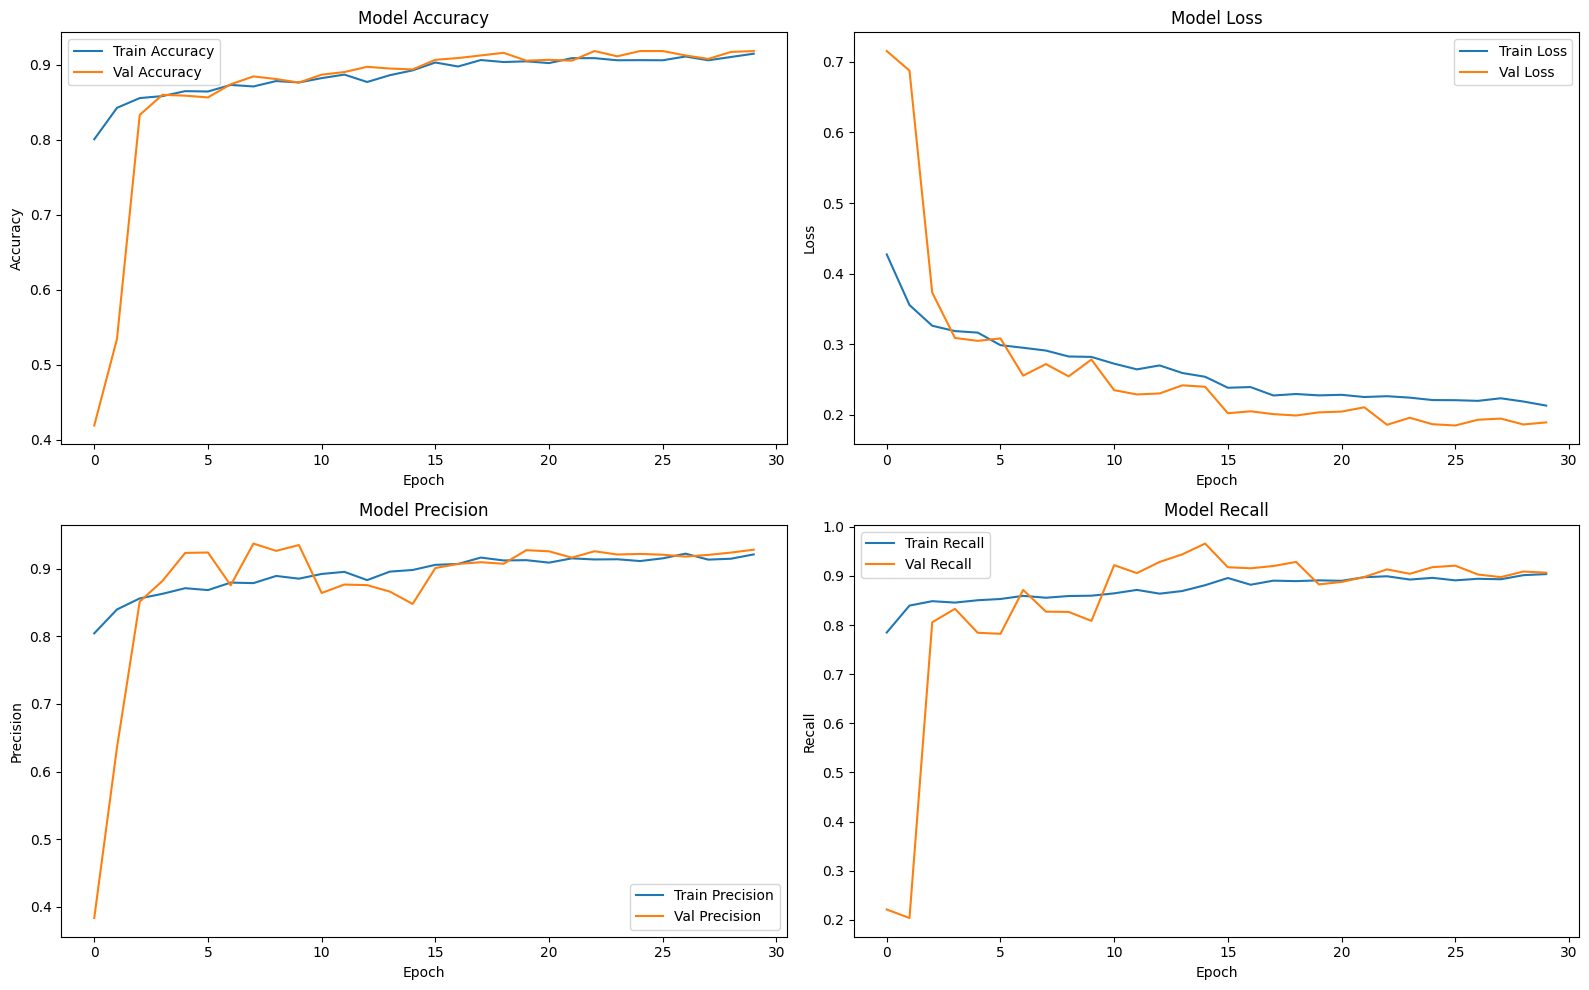

In [5]:
import os

# 1. Professional Callback Suite
# Innovation: Saving the best model and managing learning dynamics
checkpoint_path = "best_acne_model_V2.keras"

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# 2. Execute Training
history = model.fit(
    train_ds,
    epochs=30,
    validation_data=validation_ds,
    callbacks=callbacks
)

# 3. Comprehensive Visualization (Engineering Level)
# Plotting Accuracy, Loss, and Medical Metrics (Precision/Recall)
def plot_metrics(history):
    metrics = ['accuracy', 'loss', 'precision', 'recall']
    plt.figure(figsize=(16, 10))

    for i, metric in enumerate(metrics):
        plt.subplot(2, 2, i+1)
        plt.plot(history.history[metric], label=f'Train {metric.capitalize()}')
        plt.plot(history.history[f'val_{metric}'], label=f'Val {metric.capitalize()}')
        plt.title(f'Model {metric.capitalize()}')
        plt.xlabel('Epoch')
        plt.ylabel(metric.capitalize())
        plt.legend()

    plt.tight_layout()
    plt.show()

plot_metrics(history)

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
import matplotlib.pyplot as plt
import numpy as np # FIX: Essential for evaluation
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Keep your drive mount and data generators as they were

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━

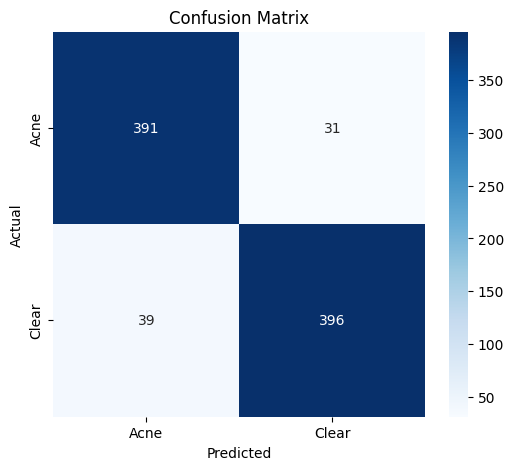

In [7]:
# 1. Collect true labels and predictions
y_true = []
y_pred_probs = []

# Iterate through validation set to get raw data
for images, labels in validation_ds:
    y_true.extend(labels.numpy())
    probs = model.predict(images)
    y_pred_probs.extend(probs.flatten())

# 2. Convert probabilities to binary classes (0 or 1)
# Because your last layer is 'sigmoid', output is 0.0 to 1.0
y_pred = [1 if p > 0.5 else 0 for p in y_pred_probs]

# 3. Professional Metrics Table
print("--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Acne', 'Clear']))

# 4. Confusion Matrix (Visual Error Analysis)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Acne', 'Clear'], yticklabels=['Acne', 'Clear'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

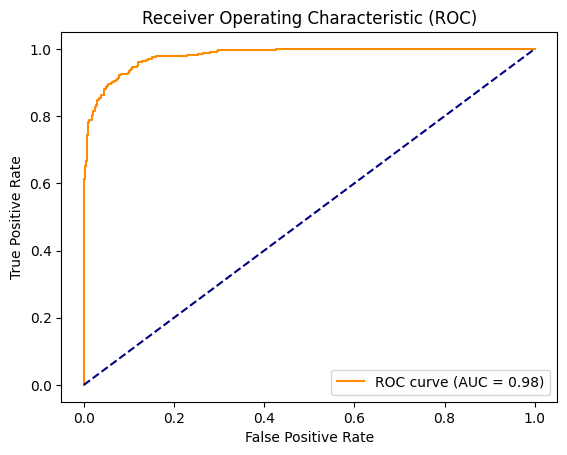

In [8]:
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━

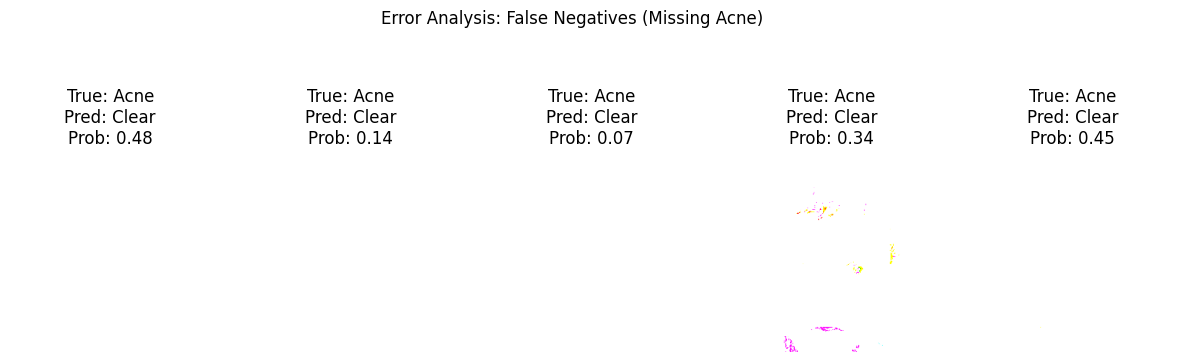

In [9]:
# Identify the most confident mistakes
y_true = []
y_pred_probs = []
all_images = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())
    probs = model.predict(images)
    y_pred_probs.extend(probs.flatten())
    all_images.extend(images.numpy())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred = (y_pred_probs > 0.5).astype(int)

# Finding False Negatives (Actual Acne, Predicted Clear)
# These are the most dangerous errors in medical AI.
fn_indices = np.where((y_true == 1) & (y_pred == 0))[0]

plt.figure(figsize=(15, 5))
for i, idx in enumerate(fn_indices[:5]):
    plt.subplot(1, 5, i+1)
    plt.imshow(all_images[idx])
    plt.title(f"True: Acne\nPred: Clear\nProb: {y_pred_probs[idx]:.2f}")
    plt.axis('off')
plt.suptitle("Error Analysis: False Negatives (Missing Acne)")
plt.show()

In [10]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score

y_true = []
y_scores = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_scores.extend(preds.flatten())
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_scores = np.array(y_scores)

In [11]:
thresholds = np.arange(0.1, 0.91, 0.05)

for t in thresholds:
    y_pred = (y_scores >= t).astype(int)
    print(f"\nThreshold: {t:.2f}")
    print(confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred, target_names=['Acne', 'Normal']))


Threshold: 0.10
[[325 126]
 [  3 410]]
              precision    recall  f1-score   support

        Acne       0.99      0.72      0.83       451
      Normal       0.76      0.99      0.86       413

    accuracy                           0.85       864
   macro avg       0.88      0.86      0.85       864
weighted avg       0.88      0.85      0.85       864


Threshold: 0.15
[[349 102]
 [  6 407]]
              precision    recall  f1-score   support

        Acne       0.98      0.77      0.87       451
      Normal       0.80      0.99      0.88       413

    accuracy                           0.88       864
   macro avg       0.89      0.88      0.87       864
weighted avg       0.90      0.88      0.87       864


Threshold: 0.20
[[371  80]
 [  7 406]]
              precision    recall  f1-score   support

        Acne       0.98      0.82      0.90       451
      Normal       0.84      0.98      0.90       413

    accuracy                           0.90       864
   macro

Number of actual Normal images in test set: 410


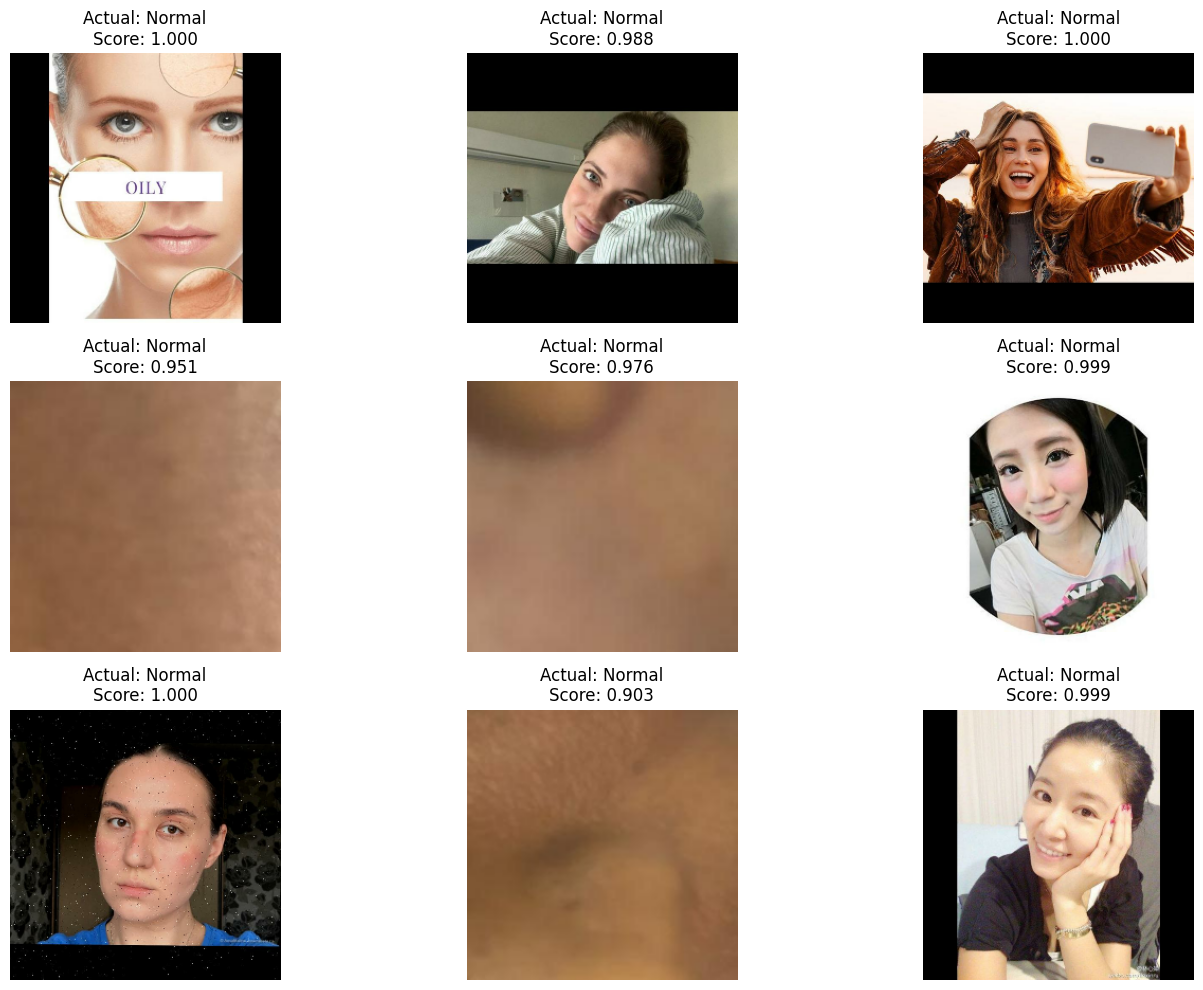

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Collect test images and labels
x_test = []
y_test = []

for images, labels in test_ds:
    x_test.extend(images.numpy())
    y_test.extend(labels.numpy())

x_test = np.array(x_test)
y_test = np.array(y_test)

# Predict on test set
scores = model.predict(x_test, verbose=0).flatten()

# Find actual Normal images (class 1)
normal_indices = np.where(y_test == 1)[0]

print("Number of actual Normal images in test set:", len(normal_indices))

# Show 9 actual normal images with their scores
plt.figure(figsize=(15, 10))
for i, idx in enumerate(normal_indices[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[idx].astype("uint8"))
    plt.title(f"Actual: Normal\nScore: {scores[idx]:.3f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

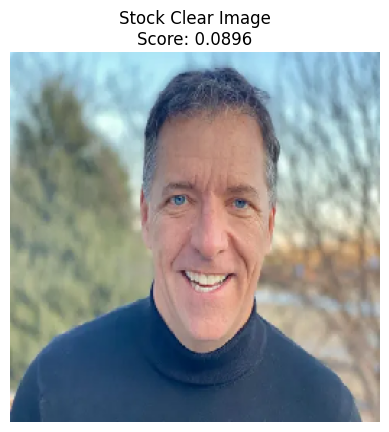

Predicted score: 0.08964969
Predicted label: Acne


In [23]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/gdrive/MyDrive/Normal_Image1.webp"

img = load_img(img_path, target_size=(256, 256))
img_array = img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)

score = model.predict(img_batch, verbose=0)[0][0]

plt.imshow(img)
plt.title(f"Stock Clear Image\nScore: {score:.4f}")
plt.axis("off")
plt.show()

print("Predicted score:", score)
print("Predicted label:", "Clear" if score >= 0.20 else "Acne")

Number of actual Acne images in test set: 446


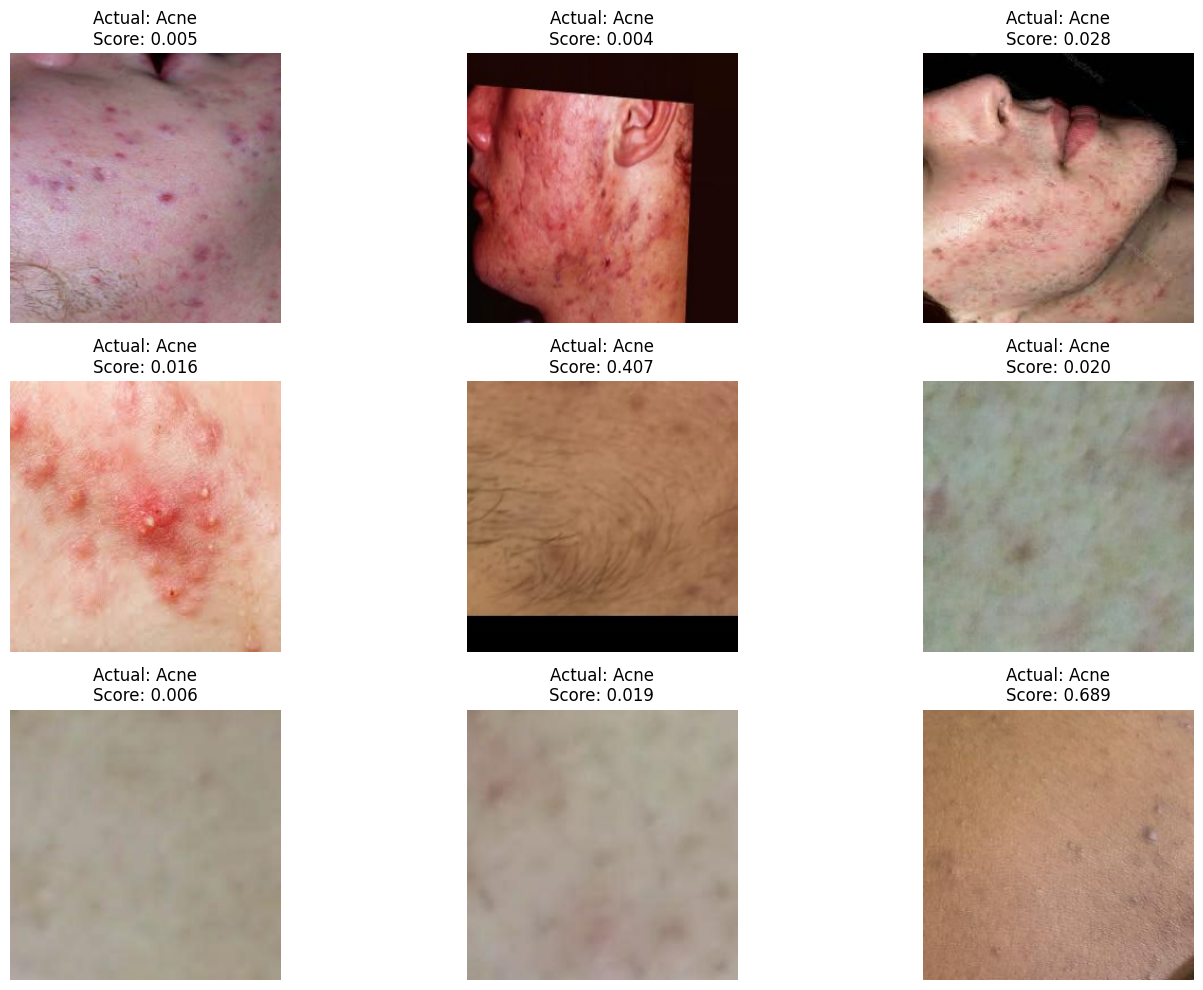

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Collect test images and labels
x_test = []
y_test = []

for images, labels in test_ds:
    x_test.extend(images.numpy())
    y_test.extend(labels.numpy())

x_test = np.array(x_test)
y_test = np.array(y_test)

# Predict scores
scores = model.predict(x_test, verbose=0).flatten()

# Actual Acne images are class 0
acne_indices = np.where(y_test == 0)[0]

print("Number of actual Acne images in test set:", len(acne_indices))

# Show 9 actual acne images with scores
plt.figure(figsize=(15, 10))
for i, idx in enumerate(acne_indices[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[idx].astype("uint8"))
    plt.title(f"Actual: Acne\nScore: {scores[idx]:.3f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
# Step 1: Save the current in-memory model
model.save("debug_export.keras")

# Step 2: Reload the saved model from disk
reloaded_model = tf.keras.models.load_model("debug_export.keras")

# Step 3: Predict again on the same stock clear image
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/gdrive/MyDrive/istockphoto-1272479912-612x612.jpg"

img = load_img(img_path, target_size=(256, 256))
img_array = img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)

score_original = model.predict(img_batch, verbose=0)[0][0]
score_reloaded = reloaded_model.predict(img_batch, verbose=0)[0][0]

print("Original in-memory model score:", score_original)
print("Reloaded saved-model score:", score_reloaded)

Original in-memory model score: 0.07360137
Reloaded saved-model score: 0.07360137


In [16]:
from PIL import Image

img_path = "/content/gdrive/MyDrive/istockphoto-1272479912-612x612.jpg"
img = Image.open(img_path)

print("Colab image size:", img.size)
print("Colab image mode:", img.mode)

Colab image size: (459, 612)
Colab image mode: RGB


In [17]:
import tensorflow as tf
import keras

print("Colab TensorFlow version:", tf.__version__)
print("Colab Keras version:", keras.__version__)

Colab TensorFlow version: 2.19.0
Colab Keras version: 3.13.2
